# Offline Reinforcement Learning: Dataset → CQL from Scratch → CQL Library → BCQ

## Portfolio Project

This notebook builds an offline reinforcement learning project from the data level upward.

The progression is:

```text
Minari Offline Dataset
        ↓
Inspect EVERYTHING
        ↓
Understand episodes and transitions
        ↓
CQL from scratch
        ↓
CQL with d3rlpy
        ↓
Discrete BCQ with d3rlpy
        ↓
Gymnasium evaluation
        ↓
Compare all methods
```

### Main principle

**No training method collects new experience from the environment.**

Training uses only the fixed Minari dataset.

Gymnasium is used after training to evaluate the learned policies.

## What Is This Dataset About?

This project uses:

```text
D4RL/minigrid/fourrooms-random-v0
```

The dataset contains **previously recorded navigation trajectories** from the MiniGrid FourRooms environment.

The FourRooms task contains:

```text
four connected rooms
        ↓
an agent
        ↓
doorways between rooms
        ↓
a goal location
```

The recorded behavior policy is **random**.

That means the dataset is not a collection of expert demonstrations. It contains experience generated by an agent that selected actions randomly while moving through the environment.

Each recorded transition provides:

$$
(s_t,\ a_t,\ r_t,\ s_{t+1})
$$

together with episode-ending information.

So the dataset is best understood as:

> **A fixed history of how a randomly acting agent moved through FourRooms, which actions it chose, what reward it received, and what state followed.**

## What Is the Offline RL Agent Trying to Learn?

The offline RL algorithm receives only the fixed dataset.

It does **not** collect new training experience while learning.

The goal is to learn a policy:

$$
\pi(s) \rightarrow a
$$

that answers:

> **Given the current FourRooms state, which action should the agent choose to maximize long-term reward and reach the goal more successfully?**

For this project:

```text
STATE
  ↓
7 × 7 × 3 encoded grid
+
agent direction

POLICY
  ↓

ACTION
  ↓
turn left
turn right
move forward
...
```

The desired behavior is:

```text
understand the current local grid
        ↓
use the direction information
        ↓
choose effective navigation actions
        ↓
reach the goal
```

The learning objective is to maximize cumulative discounted reward:

$$
\max_\pi
\mathbb{E}
\left[
\sum_t \gamma^t r_t
\right]
$$

The key offline-RL restriction is:

> **The policy must learn this only from the recorded Minari dataset, without generating new training trajectories.**

## Dataset and Learning Problem at a Glance

| Question | Answer |
|---|---|
| **Environment** | MiniGrid FourRooms |
| **Task** | Navigate through four connected rooms and reach the goal |
| **Dataset source** | Random behavior policy |
| **State** | Encoded local grid + agent direction |
| **Action** | One of seven discrete MiniGrid actions |
| **Reward** | Reward associated with successful/efficient goal reaching |
| **Offline RL input** | Fixed recorded transitions |
| **What the policy learns** | Which action to choose from each state |
| **Final objective** | Maximize long-term return and reach the goal |

## 1. What Is Offline Reinforcement Learning?

In online RL:

```text
Agent → Action → Environment → New Experience → Learning
```

The agent can keep collecting new transitions during training.

In offline RL:

```text
Existing Dataset → Learning
```

The agent receives a fixed collection of transitions:

$$
(s_t,\ a_t,\ r_t,\ s_{t+1})
$$

together with episode-boundary information.

This is useful when real-world interaction is expensive, dangerous, slow, or no longer available.

## 2. Install the Required Packages

The project uses three different RL-related tools for different purposes:

- **Minari** — offline dataset storage and download
- **Gymnasium** — environment API and evaluation
- **d3rlpy** — deep offline RL algorithms

Gymnasium itself does **not** implement CQL or BCQ.

In [ ]:
# Install the project dependencies in a fresh environment.
# The line is commented so that an already-configured environment is not changed automatically.

# %pip install -r ../requirements.txt

In [2]:
# ============================================================
# Install Required Libraries
# ============================================================
# Google Colab does not include Minari by default.
# This cell installs Minari and the other libraries required
# for the offline reinforcement learning notebook.

%pip install -q minari gymnasium numpy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.0 MB/s eta 0:00:00


In [39]:
# ============================================================
# Install Required Libraries
# ============================================================
# Minari stores offline RL datasets.
# Gymnasium provides the RL environment interface.
# MiniGrid is required to reconstruct MiniGrid environments
# associated with some Minari datasets.

%pip install -q minari gymnasium minigrid numpy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 89.2 MB/s eta 0:00:00


## 3. Import Packages and Print Versions

Before analyzing the dataset, print the versions of the main libraries.

This is useful for reproducibility because offline-RL APIs can change between library versions.

In [40]:
# Import packages used for dataset inspection, library-based training, evaluation, and plotting.

import sys
import minari
import gymnasium as gym
import minigrid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:    ", sys.version)
print("Minari:    ", minari.__version__)
print("Gymnasium: ", gym.__version__)
print("MiniGrid:  ", minigrid.__version__)
print("NumPy:     ", np.__version__)
print("Pandas:    ", pd.__version__)

Python:     3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Minari:     0.5.3
Gymnasium:  1.3.0
MiniGrid:   3.1.0
NumPy:      2.1.3
Pandas:     2.2.3


# Part I — Inspect the Offline Dataset Completely

Before writing any reinforcement-learning algorithm, we first answer:

> **What exactly is inside this dataset?**

We will inspect the dataset object, observation space, every state feature, action space, episode structure, reward, termination, truncation, transition structure, and global statistics.

## 4. Load the Minari Dataset

Dataset:

```text
D4RL/minigrid/fourrooms-random-v0
```

`download=True` downloads the dataset if it is not already stored locally.

In [4]:
# Load the fixed offline dataset.

DATASET_ID = "D4RL/minigrid/fourrooms-random-v0"

dataset = minari.load_dataset(
    DATASET_ID,
    download=True
)

print("Dataset loaded successfully.")

namespace_metadata.json:   0%|          | 0.00/1.86k [00:00<?, ?B/s]

metadata.json:   0%|          | 0.00/2.96k [00:00<?, ?B/s]

namespace_metadata.json:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

namespace_metadata.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

namespace_metadata.json:   0%|          | 0.00/3.26k [00:00<?, ?B/s]

...

namespace_metadata.json:   0%|          | 0.00/1.86k [00:00<?, ?B/s]

namespace_metadata.json:   0%|          | 0.00/641 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]


Dataset D4RL/minigrid/fourrooms-random-v0 downloaded to /root/.minari/datasets/D4RL/minigrid/fourrooms-random-v0
Dataset loaded successfully.


## 5. Inspect the Dataset Object and High-Level Metadata

This cell prints the most basic structural information:

- Python object type
- dataset ID
- number of episodes
- total recorded transitions
- complete observation space
- complete action space

In [5]:
# Print high-level dataset information.

print("=" * 70)
print("DATASET OBJECT")
print("=" * 70)

print("Python type:")
print(type(dataset))

print("\nDataset ID:")
print(DATASET_ID)

print("\nTotal episodes:")
print(dataset.total_episodes)

print("\nTotal transitions / steps:")
print(dataset.total_steps)

print("\nComplete observation space:")
print(dataset.observation_space)

print("\nComplete action space:")
print(dataset.action_space)

DATASET OBJECT
Python type:
<class 'minari.dataset.minari_dataset.MinariDataset'>

Dataset ID:
D4RL/minigrid/fourrooms-random-v0

Total episodes:
10174

Total transitions / steps:
1000070

Complete observation space:
Dict('direction': Discrete(4), 'image': Box(0, 255, (7, 7, 3), uint8), 'mission': Text(1, 14, charset=                                                              ''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''(),,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdeeeffghijklmnnoopqrrssttuvwxyzz{}))

Complete action space:
Discrete(7)


## 6. Inspect Every Observation-Space Feature

The observation is a dictionary rather than a single vector.

We print each component separately so that the state space is completely clear.

In [6]:
# Print each observation-space component individually.

print("=" * 70)
print("OBSERVATION SPACE BY FEATURE")
print("=" * 70)

for feature_name, feature_space in dataset.observation_space.spaces.items():

    print(f"\nFeature: {feature_name}")
    print("Space:", feature_space)

    if hasattr(feature_space, "shape"):
        print("Shape:", feature_space.shape)

    if hasattr(feature_space, "dtype"):
        print("Data type:", feature_space.dtype)

    if hasattr(feature_space, "n"):
        print("Number of discrete values:", feature_space.n)

OBSERVATION SPACE BY FEATURE

Feature: direction
Space: Discrete(4)
Shape: ()
Data type: int64
Number of discrete values: 4

Feature: image
Space: Box(0, 255, (7, 7, 3), uint8)
Shape: (7, 7, 3)
Data type: uint8

Feature: mission
Space: Text(1, 14, charset=                                                              ''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''(),,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdeeeffghijklmnnoopqrrssttuvwxyzz{})
Shape: None
Data type: <U0


## 7. Inspect Image-Space Bounds and Shape

The `image` feature has shape `(7, 7, 3)`.

Therefore:

\[
7 	imes 7 	imes 3 = 147
\]

encoded numeric values are present in this part of the state.

In [7]:
# Inspect the numeric bounds and size of the image observation.

image_space = dataset.observation_space["image"]

print("Image space:")
print(image_space)

print("\nImage shape:")
print(image_space.shape)

print("\nImage data type:")
print(image_space.dtype)

print("\nNumber of encoded image values:")
print(np.prod(image_space.shape))

print("\nMinimum allowed encoded value:")
print(np.min(image_space.low))

print("\nMaximum allowed encoded value:")
print(np.max(image_space.high))

Image space:
Box(0, 255, (7, 7, 3), uint8)

Image shape:
(7, 7, 3)

Image data type:
uint8

Number of encoded image values:
147

Minimum allowed encoded value:
0

Maximum allowed encoded value:
255


## 8. Inspect Direction and Mission Spaces

`direction` represents the agent orientation.

`mission` is text. In this FourRooms task the mission is effectively fixed, so later we will exclude the mission text from the numeric vector used by deep RL.

In [8]:
# Print direction and mission spaces separately.

direction_space = dataset.observation_space["direction"]
mission_space = dataset.observation_space["mission"]

print("Direction space:")
print(direction_space)

print("\nNumber of possible directions:")
print(direction_space.n)

print("\nMission space:")
print(mission_space)

Direction space:
Discrete(4)

Number of possible directions:
4

Mission space:
Text(1, 14, charset=                                                              ''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''(),,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdeeeffghijklmnnoopqrrssttuvwxyzz{})


## 9. Inspect the Action Space

The dataset uses a discrete action space.

We print both the machine-readable space and a human-readable mapping.

In [9]:
# Print the action-space structure.

print("Action space:")
print(dataset.action_space)

print("\nNumber of possible actions:")
print(dataset.action_space.n)

Action space:
Discrete(7)

Number of possible actions:
7


## 10. Human-Readable Action Mapping

MiniGrid defines seven actions.

For this navigation task, turning and moving forward are the actions that matter most, but the full environment action space still contains seven actions.

In [10]:
# Map action integers to readable names.

ACTION_NAMES = {
    0: "Turn left",
    1: "Turn right",
    2: "Move forward",
    3: "Pick up",
    4: "Drop",
    5: "Toggle",
    6: "Done",
}

for action_id, action_name in ACTION_NAMES.items():
    print(f"{action_id} -> {action_name}")

0 -> Turn left
1 -> Turn right
2 -> Move forward
3 -> Pick up
4 -> Drop
5 -> Toggle
6 -> Done


## 11. Load One Complete Episode

Minari stores trajectories as episodes.

We first inspect one complete episode before looking at individual transitions.

In [11]:
# Retrieve the first complete episode.

episode = next(dataset.iterate_episodes())

print("Episode object type:")
print(type(episode))

print("\nEpisode ID:")
print(episode.id)

Episode object type:
<class 'minari.dataset.episode_data.EpisodeData'>

Episode ID:
0


## 12. Inspect Every Field in the Episode

We inspect:

- observations
- actions
- rewards
- terminations
- truncations
- infos, if present

In [12]:
# Print the structure and data type of every major episode field.

print("=" * 70)
print("EPISODE STRUCTURE")
print("=" * 70)

print("\nObservation container type:")
print(type(episode.observations))

print("\nObservation keys:")
print(episode.observations.keys())

for key, value in episode.observations.items():

    print(f"\nObservation feature: {key}")
    print("Python type:", type(value))

    if hasattr(value, "shape"):
        print("Shape:", value.shape)

    if hasattr(value, "dtype"):
        print("Data type:", value.dtype)

print("\nActions")
print("Type:", type(episode.actions))
print("Shape:", episode.actions.shape)
print("Data type:", episode.actions.dtype)

print("\nRewards")
print("Type:", type(episode.rewards))
print("Shape:", episode.rewards.shape)
print("Data type:", episode.rewards.dtype)

print("\nTerminations")
print("Type:", type(episode.terminations))
print("Shape:", episode.terminations.shape)
print("Data type:", episode.terminations.dtype)

print("\nTruncations")
print("Type:", type(episode.truncations))
print("Shape:", episode.truncations.shape)
print("Data type:", episode.truncations.dtype)

print("\nInfos")
print("Type:", type(episode.infos))

if episode.infos is not None:
    try:
        print("Info keys:", episode.infos.keys())
    except AttributeError:
        print("Infos do not use dictionary-style keys.")

EPISODE STRUCTURE

Observation container type:
<class 'dict'>

Observation keys:
dict_keys(['direction', 'image', 'mission'])

Observation feature: direction
Python type: <class 'numpy.ndarray'>
Shape: (101,)
Data type: int64

Observation feature: image
Python type: <class 'numpy.ndarray'>
Shape: (101, 7, 7, 3)
Data type: uint8

Observation feature: mission
Python type: <class 'list'>

Actions
Type: <class 'numpy.ndarray'>
Shape: (100,)
Data type: int64

Rewards
Type: <class 'numpy.ndarray'>
Shape: (100,)
Data type: int64

Terminations
Type: <class 'numpy.ndarray'>
Shape: (100,)
Data type: bool

Truncations
Type: <class 'numpy.ndarray'>
Shape: (100,)
Data type: bool

Infos
Type: <class 'dict'>
Info keys: dict_keys([])


## 13. Verify Why Observations Have Length \(T+1\)

Suppose an episode has \(T\) actions.

The episode needs:

$$
s_0, a_0, r_0, s_1
$$

then:

$$
s_1, a_1, r_1, s_2
$$

and so on.

Therefore an episode with \(T\) actions needs **\(T+1\) observations**.

This is what allows us to recover every `next_state`.

In [13]:
# Verify the T+1 observation relationship.

num_observations = len(
    episode.observations["direction"]
)

num_actions = len(
    episode.actions
)

num_rewards = len(
    episode.rewards
)

num_terminations = len(
    episode.terminations
)

num_truncations = len(
    episode.truncations
)

print("Observations:", num_observations)
print("Actions:", num_actions)
print("Rewards:", num_rewards)
print("Terminations:", num_terminations)
print("Truncations:", num_truncations)

print(
    "\nObservations = Actions + 1:",
    num_observations == num_actions + 1
)

print(
    "Actions = Rewards = Terminations = Truncations:",
    num_actions
    == num_rewards
    == num_terminations
    == num_truncations
)

Observations: 101
Actions: 100
Rewards: 100
Terminations: 100
Truncations: 100

Observations = Actions + 1: True
Actions = Rewards = Terminations = Truncations: True


## 14. Print Actual Values from the First State

Shapes alone are not enough.

This cell prints the actual first state so that we can see what the encoded data look like.

In [14]:
# Print the actual state features at time t=0.

t = 0

print("Direction value:")
print(episode.observations["direction"][t])

print("\nMission:")
print(episode.observations["mission"][t])

print("\nImage shape:")
print(episode.observations["image"][t].shape)

print("\nEncoded 7 x 7 x 3 image:")
print(episode.observations["image"][t])

Direction value:
0

Mission:
reach the goal

Image shape:
(7, 7, 3)

Encoded 7 x 7 x 3 image:
[[[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[2 5 0]
  [2 5 0]
  [2 5 0]
  [2 5 0]
  [2 5 0]
  [2 5 0]
  [2 5 0]]]


## 15. Print One Complete Offline-RL Transition

This is the most important data structure in the project.

We print:

$$
(s_t,\ a_t,\ r_t,\ s_{t+1},\ terminated,\ truncated,\ done)
$$

where:

```text
done = terminated OR truncated
```

In [15]:
# Print one complete transition in a readable form.

t = 0

state_direction = int(
    episode.observations["direction"][t]
)

state_image = episode.observations["image"][t]

action = int(
    episode.actions[t]
)

reward = float(
    episode.rewards[t]
)

next_state_direction = int(
    episode.observations["direction"][t + 1]
)

next_state_image = episode.observations["image"][t + 1]

terminated = bool(
    episode.terminations[t]
)

truncated = bool(
    episode.truncations[t]
)

done = terminated or truncated


print("=" * 70)
print("ONE COMPLETE OFFLINE RL TRANSITION")
print("=" * 70)

print("\nSTATE s_t")
print("Direction:", state_direction)
print("Image shape:", state_image.shape)
print(state_image)

print("\nACTION a_t")
print("Action ID:", action)
print("Action name:", ACTION_NAMES[action])

print("\nREWARD r_t")
print(reward)

print("\nNEXT STATE s_(t+1)")
print("Direction:", next_state_direction)
print("Image shape:", next_state_image.shape)
print(next_state_image)

print("\nEPISODE FLAGS")
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Done:", done)

ONE COMPLETE OFFLINE RL TRANSITION

STATE s_t
Direction: 0
Image shape: (7, 7, 3)
[[[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[2 5 0]
  [2 5 0]
  [2 5 0]
  [2 5 0]
  [2 5 0]
  [2 5 0]
  [2 5 0]]]

ACTION a_t
Action ID: 6
Action name: Done

REWARD r_t
0.0

NEXT STATE s_(t+1)
Direction: 0
Image shape: (7, 7, 3)
[[[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
  [1 0 0]
  [1 0 0]
  [2 5 0]
  [1 0 0]
  [1 0 0]
  [1 0 0]]

 [[1 0 0]
 

## 16. Terminated vs Truncated vs Done

These terms should not be treated as identical.

### `terminated`

The environment reached a true terminal condition.

Examples:

- success
- failure
- absorbing terminal state

### `truncated`

The episode was stopped by an external condition rather than the underlying task naturally ending.

Examples:

- time limit
- data collection cutoff

### `done`

For simple episode iteration:

```python
done = terminated or truncated
```

However, for Bellman bootstrapping, a time-limit truncation is often treated differently from a true terminal state.

In the from-scratch CQL training below, we stop bootstrapping only for **true termination** while retaining the distinction explicitly.

## 17. Summarize the First Episode

Now that the structure is clear, calculate basic episode-level quantities:

- number of actions
- total return
- positive reward count
- whether the episode ends through termination
- whether it ends through truncation

In [16]:
# Summarize the selected episode.

episode_return = float(
    np.sum(episode.rewards)
)

positive_rewards = int(
    np.sum(episode.rewards > 0)
)

print("Episode length:", len(episode.actions))
print("Episode return:", episode_return)
print("Positive rewards:", positive_rewards)

print(
    "Contains termination:",
    bool(np.any(episode.terminations))
)

print(
    "Contains truncation:",
    bool(np.any(episode.truncations))
)

Episode length: 100
Episode return: 0.0
Positive rewards: 0
Contains termination: False
Contains truncation: True


## 18. Preview the First 10 Transitions as a Table

A compact table helps connect the episode representation to standard transition data.

In [17]:
# Create a readable transition preview.

preview_rows = []

for t in range(
    min(10, len(episode.actions))
):

    terminated = bool(
        episode.terminations[t]
    )

    truncated = bool(
        episode.truncations[t]
    )

    preview_rows.append(
        {
            "t": t,
            "state_direction": int(
                episode.observations["direction"][t]
            ),
            "action": int(
                episode.actions[t]
            ),
            "action_name": ACTION_NAMES[
                int(episode.actions[t])
            ],
            "reward": float(
                episode.rewards[t]
            ),
            "next_direction": int(
                episode.observations["direction"][t + 1]
            ),
            "terminated": terminated,
            "truncated": truncated,
            "done": terminated or truncated,
        }
    )

transition_preview = pd.DataFrame(
    preview_rows
)

transition_preview

,t,state_direction,action,action_name,reward,next_direction,terminated,truncated,done
0,0,0,6,Done,0.0,0,False,False,False
1,1,0,3,Pick up,0.0,0,False,False,False
2,2,0,3,Pick up,0.0,0,False,False,False
3,3,0,1,Turn right,0.0,1,False,False,False
4,4,1,4,Drop,0.0,1,False,False,False
5,5,1,0,Turn left,0.0,0,False,False,False
6,6,0,2,Move forward,0.0,0,False,False,False
7,7,0,2,Move forward,0.0,0,False,False,False
8,8,0,1,Turn right,0.0,1,False,False,False
9,9,1,2,Move forward,0.0,1,False,False,False


## 19. Scan the Entire Dataset for Global Statistics

We now summarize all episodes.

The scan collects:

- action counts
- total reward values
- episode returns
- episode lengths
- successful episodes
- termination count
- truncation count
- mission examples
- total transitions reconstructed from episodes

This confirms that our interpretation of the dataset matches the dataset metadata.

In [18]:
# Scan the complete dataset once and collect global statistics.

action_counts = {
    action: 0
    for action in range(dataset.action_space.n)
}

all_rewards = []
episode_returns = []
episode_lengths = []

successful_episodes = 0
termination_count = 0
truncation_count = 0

mission_examples = set()

reconstructed_transition_count = 0


for ep in dataset.iterate_episodes():

    episode_lengths.append(
        len(ep.actions)
    )

    ep_return = float(
        np.sum(ep.rewards)
    )

    episode_returns.append(
        ep_return
    )

    if ep_return > 0:
        successful_episodes += 1

    reconstructed_transition_count += len(
        ep.actions
    )

    all_rewards.extend(
        float(r)
        for r in ep.rewards
    )

    for action in ep.actions:
        action_counts[int(action)] += 1

    termination_count += int(
        np.sum(ep.terminations)
    )

    truncation_count += int(
        np.sum(ep.truncations)
    )

    for mission in ep.observations["mission"][:1]:
        mission_examples.add(
            str(mission)
        )


print("Reconstructed transitions:")
print(reconstructed_transition_count)

print("\nDataset-reported transitions:")
print(dataset.total_steps)

print(
    "\nCounts match:",
    reconstructed_transition_count
    == dataset.total_steps
)

print("\nMission examples:")
print(mission_examples)

Reconstructed transitions:
1000070

Dataset-reported transitions:
1000070

Counts match: True

Mission examples:
{'reach the goal'}


## 20. Global Action Distribution

The data were generated by a random policy, so action coverage is an important dataset characteristic.

We show both counts and percentages.

In [19]:
# Build the action-distribution table.

action_distribution = pd.DataFrame(
    {
        "Action": list(action_counts.keys()),
        "Action Name": [
            ACTION_NAMES[a]
            for a in action_counts.keys()
        ],
        "Count": list(action_counts.values()),
    }
)

action_distribution["Percentage"] = (
    action_distribution["Count"]
    /
    action_distribution["Count"].sum()
    * 100
)

action_distribution

,Action,Action Name,Count,Percentage
0,0,Turn left,143454,14.344396
1,1,Turn right,142333,14.232304
2,2,Move forward,142965,14.295499
3,3,Pick up,142997,14.298699
4,4,Drop,142679,14.266901
5,5,Toggle,142578,14.256802
6,6,Done,143064,14.305399


## 21. Plot the Action Distribution

This plot provides a quick visual check of behavior-policy action coverage.

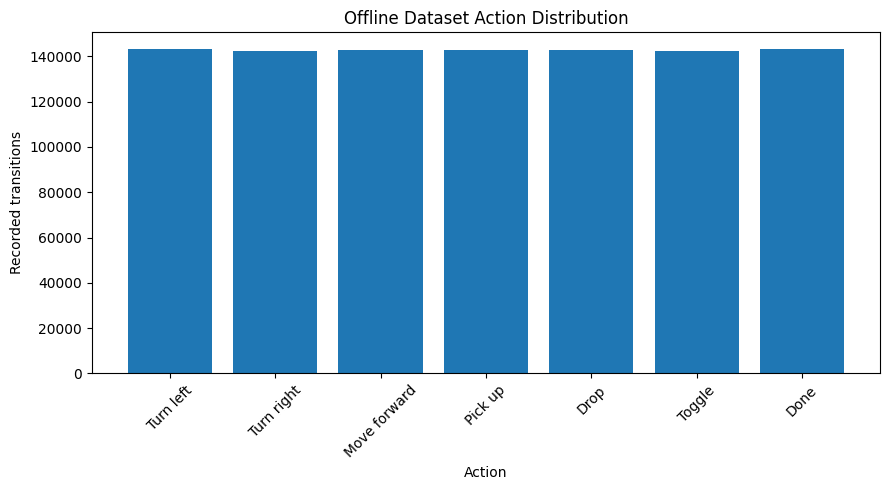

In [20]:
# Plot action frequencies.

plt.figure(figsize=(9, 5))

plt.bar(
    action_distribution["Action Name"],
    action_distribution["Count"]
)

plt.xlabel("Action")
plt.ylabel("Recorded transitions")
plt.title("Offline Dataset Action Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 22. Global Reward Statistics

Offline RL depends strongly on the reward information contained in the dataset.

For sparse-reward tasks, most transitions may carry zero reward, making successful trajectories especially important.

In [21]:
# Summarize transition-level rewards.

reward_series = pd.Series(
    all_rewards,
    name="reward"
)

print(reward_series.describe())

print("\nPositive-reward transitions:")
print(int((reward_series > 0).sum()))

print("\nZero-reward transitions:")
print(int((reward_series == 0).sum()))

print("\nPercentage positive:")
print(
    round(
        float((reward_series > 0).mean() * 100),
        4
    )
)

count    1.000070e+06
mean     1.874569e-04
std      1.152477e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.910000e-01
Name: reward, dtype: float64

Positive-reward transitions:
315

Zero-reward transitions:
999755

Percentage positive:
0.0315


## 23. Episode Return Statistics

The episode return is the sum of rewards obtained during an episode.

This is more informative than looking only at individual transition rewards.

In [22]:
# Summarize episode returns.

episode_return_series = pd.Series(
    episode_returns,
    name="episode_return"
)

print(episode_return_series.describe())

print("\nSuccessful episodes:")
print(successful_episodes)

print("\nTotal episodes:")
print(len(episode_returns))

print("\nDataset behavior success rate:")
print(
    round(
        successful_episodes
        /
        len(episode_returns)
        *
        100,
        4
    ),
    "%"
)

count    10174.000000
mean         0.018426
std          0.112787
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.991000
Name: episode_return, dtype: float64

Successful episodes:
315

Total episodes:
10174

Dataset behavior success rate:
3.0961 %


## 24. Plot the Episode Return Distribution

The distribution shows how much successful experience is available to learn from.

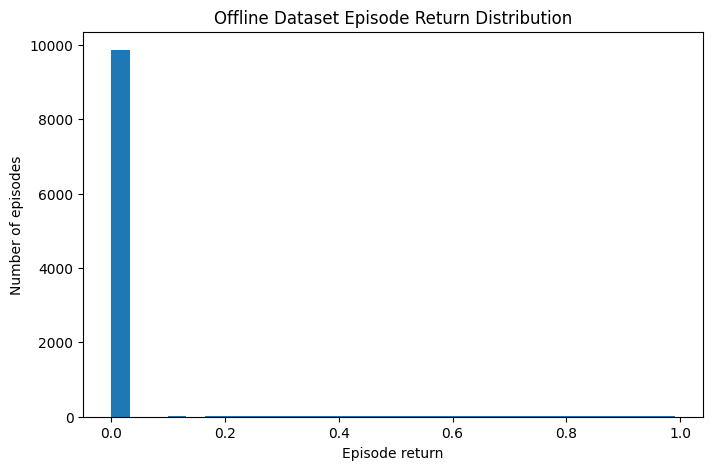

In [23]:
# Plot recorded episode returns.

plt.figure(figsize=(8, 5))

plt.hist(
    episode_returns,
    bins=30
)

plt.xlabel("Episode return")
plt.ylabel("Number of episodes")
plt.title("Offline Dataset Episode Return Distribution")
plt.show()

## 25. Episode Length Statistics

Episode length tells us how long the recorded trajectories are and how variable the behavior data are.

In [24]:
# Summarize episode lengths.

episode_length_series = pd.Series(
    episode_lengths,
    name="episode_length"
)

print(episode_length_series.describe())

count    10174.000000
mean        98.296638
std         10.800938
min          1.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: episode_length, dtype: float64


## 26. Plot Episode Length Distribution

This provides a visual summary of trajectory duration.

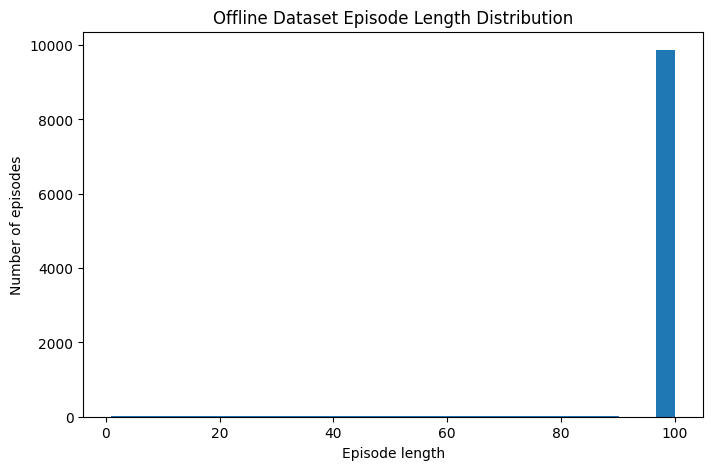

In [25]:
# Plot the distribution of recorded episode lengths.

plt.figure(figsize=(8, 5))

plt.hist(
    episode_lengths,
    bins=30
)

plt.xlabel("Episode length")
plt.ylabel("Number of episodes")
plt.title("Offline Dataset Episode Length Distribution")
plt.show()

## 27. Dataset Termination and Truncation Counts

This verifies how episode boundaries are represented globally.

In [26]:
# Print the total number of true terminations and truncations.

print("Total termination flags:")
print(termination_count)

print("\nTotal truncation flags:")
print(truncation_count)

print("\nTotal episode boundaries:")
print(termination_count + truncation_count)

print("\nTotal episodes:")
print(dataset.total_episodes)

Total termination flags:
315

Total truncation flags:
9864

Total episode boundaries:
10179

Total episodes:
10174


## 28. Final Dataset Summary Table

Before moving to RL, summarize the dataset in one portfolio-friendly table.

In [27]:
# Create a compact dataset summary.

dataset_summary = pd.DataFrame(
    {
        "Property": [
            "Dataset ID",
            "Dataset type",
            "Total episodes",
            "Total transitions",
            "Observation container",
            "Image shape",
            "Image dtype",
            "Direction space",
            "Mission",
            "Action space",
            "Number of actions",
            "Behavior success rate (%)",
            "Termination flags",
            "Truncation flags",
        ],
        "Value": [
            DATASET_ID,
            str(type(dataset).__name__),
            dataset.total_episodes,
            dataset.total_steps,
            "Dict",
            str(dataset.observation_space["image"].shape),
            str(dataset.observation_space["image"].dtype),
            str(dataset.observation_space["direction"]),
            next(iter(mission_examples)) if mission_examples else "N/A",
            str(dataset.action_space),
            dataset.action_space.n,
            round(
                successful_episodes
                /
                len(episode_returns)
                *
                100,
                4
            ),
            termination_count,
            truncation_count,
        ],
    }
)

dataset_summary

,Property,Value
0,Dataset ID,D4RL/minigrid/fourrooms-random-v0
1,Dataset type,MinariDataset
2,Total episodes,10174
3,Total transitions,1000070
4,Observation container,Dict
5,Image shape,"(7, 7, 3)"
6,Image dtype,uint8
7,Direction space,Discrete(4)
8,Mission,reach the goal
9,Action space,Discrete(7)


## 29. Define the Numeric State Representation

The deep-library algorithms need numeric observations.

The original observation contains:

```text
image     → 7 × 7 × 3 = 147 numbers
direction → 1 number
mission   → text
```

The mission is constant for this task, so we use:

\[
147 + 1 = 148
\]

numeric features.

This does **not** change the underlying environment state. It only converts the structured observation into a model-friendly vector.

In [28]:
# Convert one structured observation to a 148-element numeric vector.

def vectorize_observation(
    image,
    direction
):

    image_vector = image.reshape(-1)

    direction_vector = np.array(
        [direction],
        dtype=np.uint8
    )

    return np.concatenate(
        [
            image_vector.astype(np.uint8),
            direction_vector,
        ]
    )


example_vector = vectorize_observation(
    episode.observations["image"][0],
    episode.observations["direction"][0]
)

print("Vector shape:")
print(example_vector.shape)

print("\nVector dtype:")
print(example_vector.dtype)

print("\nNumber of numeric state features:")
print(len(example_vector))

print("\nFirst 20 values:")
print(example_vector[:20])

Vector shape:
(148,)

Vector dtype:
uint8

Number of numeric state features:
148

First 20 values:
[1 0 0 1 0 0 1 0 0 2 5 0 1 0 0 1 0 0 1 0]


# Part II — Method 1: Conservative Q-Learning (CQL)

## 30. Why Use CQL?

A central difficulty in offline RL is that the policy cannot safely test new actions and correct its mistakes.

Suppose the dataset often contains actions 0, 1, and 2 at a state but contains little or no evidence for action 5.

An ordinary Q-function can still accidentally estimate:

$$
Q(s,5) \gg Q(s,0), Q(s,1), Q(s,2)
$$

and then choose action 5.

The policy is exploiting an **estimation error**, not reliable evidence.

CQL addresses this by adding a conservative penalty:

$$
\alpha
\left[
\log\sum_a e^{Q(s,a)}
-
Q(s,a_D)
\right]
$$

to the Bellman-learning objective.

This broadly pushes Q-values downward while giving relative support to the action actually present in the dataset.

## 31. CQL — Pros, Cons, and What It Does

### What it does

- learns Q-values from a fixed dataset
- performs Bellman-style value propagation
- penalizes overly optimistic action values
- reduces attraction to unsupported actions

### What it does **not** do

- it does not create new training experience
- it does not guarantee success if the dataset lacks useful trajectories
- it does not remove the need for hyperparameter tuning
- it does not magically recover information that was never recorded

### Pros

- designed specifically for offline RL
- directly targets offline Q-value overestimation
- natural extension of Q-learning
- discrete CQL is well supported by offline-RL libraries

### Cons

- conservative coefficient `alpha` matters
- excessive conservatism can suppress useful values
- deep CQL can be computationally expensive
- performance remains dependent on dataset coverage

## 32. What “From Scratch” Means Here

The following CQL implementation does **not use an RL algorithm module**.

It manually implements the learning logic with ordinary Python data structures.

We do still use the already-loaded Minari dataset object because the purpose is to learn CQL from the real offline dataset.

The learning section manually performs:

```text
Q-table lookup
→ Bellman target
→ TD gradient
→ softmax conservative gradient
→ Q-value update
```

This is a **tabular educational adaptation of discrete CQL**, not a claim to reproduce the complete neural-network CQL paper implementation.

## 33. Create a Hashable State for Tabular CQL

For the from-scratch implementation, a state must be usable as a Python dictionary key.

We represent it as:

```text
(direction, raw_image_bytes)
```

No neural network is used in this section.

In [29]:
# Convert one Minari observation to a hashable Python state.

def make_tabular_state(
    observations,
    index
):

    direction = int(
        observations["direction"][index]
    )

    image_bytes = bytes(
        observations["image"][index]
        .reshape(-1)
        .tolist()
    )

    return (
        direction,
        image_bytes
    )


example_tabular_state = make_tabular_state(
    episode.observations,
    0
)

print("State tuple length:")
print(len(example_tabular_state))

print("\nDirection:")
print(example_tabular_state[0])

print("\nEncoded image byte length:")
print(len(example_tabular_state[1]))

State tuple length:
2

Direction:
0

Encoded image byte length:
147


## 34. Define From-Scratch CQL Hyperparameters

The important parameters are:

- `GAMMA` — discount factor
- `LEARNING_RATE` — manual tabular gradient step
- `CQL_ALPHA` — strength of conservative regularization
- `EPOCHS` — number of complete passes through the fixed dataset

In [30]:
# Define tabular CQL hyperparameters.

NUM_ACTIONS = 7

GAMMA = 0.99
LEARNING_RATE = 0.01
CQL_ALPHA = 0.10

EPOCHS = 10

EULER = 2.718281828459045

## 35. Create the Q-Table

Every newly observed state receives seven Q-values initialized to zero.

This is explicit tabular value storage, not a neural function approximator.

In [31]:
# Create the Q-table.

scratch_q = {}


def get_scratch_q_values(
    state
):

    if state not in scratch_q:

        scratch_q[state] = [
            0.0
            for _ in range(NUM_ACTIONS)
        ]

    return scratch_q[state]

## 36. Implement the Conservative Softmax Gradient Manually

For discrete CQL, the derivative of:

$$
\log \sum_a \exp Q(s,a)
$$

with respect to each Q-value is the softmax probability.

We calculate a numerically stabilized softmax manually.

No NumPy, PyTorch, or RL-library operation is needed for this update.

In [32]:
# Compute stabilized softmax probabilities using ordinary Python arithmetic.

def plain_python_softmax(
    values
):

    max_value = max(values)

    exponentials = [
        EULER ** (
            value
            -
            max_value
        )
        for value in values
    ]

    denominator = sum(
        exponentials
    )

    return [
        value / denominator
        for value in exponentials
    ]


print(
    plain_python_softmax(
        [0.0, 0.0, 0.0]
    )
)

[0.3333333333333333, 0.3333333333333333, 0.3333333333333333]


## 37. Manual CQL Update

For the recorded dataset action \(a_D\), the total objective contains:

1. a Bellman TD term
2. a conservative term

The TD gradient affects the recorded action:

$$
Q(s,a_D)-y
$$

where

$$
y =
r + \gamma \max_{a'}Q(s',a')
$$

for non-terminal transitions.

The conservative gradient for action \(j\) is:

$$
\alpha
\left[
\text{softmax}(Q(s,\cdot))_j
-
\mathbf{1}(j=a_D)
\right]
$$

The manual update therefore changes **all seven action values**:

- unsupported/high actions are pushed downward
- the recorded dataset action receives relative support
- the Bellman term still learns return information

## 38. Train CQL from Scratch Using Only the Fixed Dataset

Important:

- no `env.reset()` is used for training
- no `env.step()` is used for training
- no new experience is collected
- every update comes from Minari trajectories

For truncations, the episode has ended in the dataset but is not necessarily a true terminal MDP state. We therefore use the explicit `terminated` flag to decide whether to zero the bootstrap target.

In [33]:
# Train the manual tabular CQL implementation.

scratch_history = []


for epoch_index in range(EPOCHS):

    total_absolute_td_error = 0.0
    transition_count = 0


    for ep in dataset.iterate_episodes():

        observations = ep.observations


        for t in range(
            len(ep.actions)
        ):

            # Current state and next state.
            state = make_tabular_state(
                observations,
                t
            )

            next_state = make_tabular_state(
                observations,
                t + 1
            )

            # Logged data.
            action = int(
                ep.actions[t]
            )

            reward = float(
                ep.rewards[t]
            )

            terminated = bool(
                ep.terminations[t]
            )

            # Current Q-values.
            q_values = get_scratch_q_values(
                state
            )

            # Bellman target.
            if terminated:

                target = reward

            else:

                next_q_values = get_scratch_q_values(
                    next_state
                )

                target = (
                    reward
                    +
                    GAMMA
                    *
                    max(next_q_values)
                )

            # TD gradient for the logged action.
            td_gradient = (
                q_values[action]
                -
                target
            )

            # Conservative softmax gradient.
            action_probabilities = plain_python_softmax(
                q_values
            )

            # Update every discrete action value.
            for candidate_action in range(
                NUM_ACTIONS
            ):

                gradient = (
                    CQL_ALPHA
                    *
                    action_probabilities[
                        candidate_action
                    ]
                )

                if candidate_action == action:

                    gradient += (
                        td_gradient
                        -
                        CQL_ALPHA
                    )

                q_values[
                    candidate_action
                ] -= (
                    LEARNING_RATE
                    *
                    gradient
                )

            total_absolute_td_error += abs(
                td_gradient
            )

            transition_count += 1


    mean_absolute_td_error = (
        total_absolute_td_error
        /
        transition_count
    )

    scratch_history.append(
        {
            "Epoch": epoch_index + 1,
            "Mean Absolute TD Error":
                mean_absolute_td_error,
        }
    )

    print(
        f"Epoch {epoch_index + 1:02d}"
        f" | Mean |TD Error| = "
        f"{mean_absolute_td_error:.6f}"
    )


print("\nScratch CQL training complete.")
print("Q-table states:", len(scratch_q))

Epoch 01 | Mean |TD Error| = 0.009242
Epoch 02 | Mean |TD Error| = 0.017465
Epoch 03 | Mean |TD Error| = 0.024856
Epoch 04 | Mean |TD Error| = 0.031200
Epoch 05 | Mean |TD Error| = 0.036557
Epoch 06 | Mean |TD Error| = 0.041005
Epoch 07 | Mean |TD Error| = 0.044687
Epoch 08 | Mean |TD Error| = 0.047732
Epoch 09 | Mean |TD Error| = 0.050252
Epoch 10 | Mean |TD Error| = 0.052341

Scratch CQL training complete.
Q-table states: 23922


## 39. Plot the From-Scratch Training Diagnostic

Because this is offline training, there is no new training reward curve.

Instead, we plot the mean absolute TD error across repeated passes through the fixed dataset.

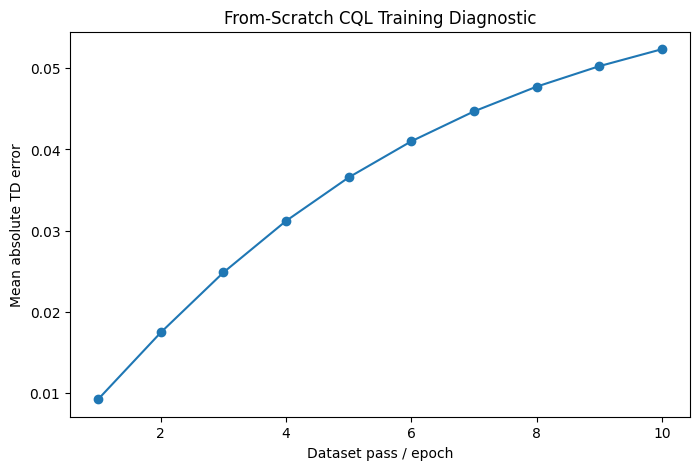

In [34]:
# Plot the manual CQL TD-error history.

scratch_history_df = pd.DataFrame(
    scratch_history
)

plt.figure(figsize=(8, 5))

plt.plot(
    scratch_history_df["Epoch"],
    scratch_history_df[
        "Mean Absolute TD Error"
    ],
    marker="o"
)

plt.xlabel("Dataset pass / epoch")
plt.ylabel("Mean absolute TD error")
plt.title("From-Scratch CQL Training Diagnostic")
plt.show()

## 40. Define the From-Scratch CQL Policy

During evaluation:

- if the current state was seen during offline training, choose the action with the highest learned Q-value
- if the state is completely unseen, use a random fallback

The fallback is necessary because a tabular method cannot generalize to unseen observations.

In [38]:
# Convert a live Gymnasium observation to the same tabular state representation.

def make_live_tabular_state(
    observation
):

    direction = int(
        observation["direction"]
    )

    image_bytes = bytes(
        observation["image"]
        .reshape(-1)
        .tolist()
    )

    return (
        direction,
        image_bytes
    )


def choose_scratch_cql_action(
    observation,
    env
):

    state = make_live_tabular_state(
        observation
    )

    if state not in scratch_q:

        return env.action_space.sample()

    q_values = scratch_q[state]

    best_action = max(
        range(NUM_ACTIONS),
        key=lambda a: q_values[a]
    )

    return best_action

## 41. Recover the Gymnasium Environment

Training is already complete.

Only now do we recover the environment for policy evaluation.

In [41]:
# Recover the original environment used to generate the dataset.

eval_env = dataset.recover_environment()

print("Recovered environment:")
print(eval_env)

print("\nObservation space:")
print(eval_env.observation_space)

print("\nAction space:")
print(eval_env.action_space)

Recovered environment:
<OrderEnforcing<PassiveEnvChecker<FourRoomsEnv<MiniGrid-FourRooms-v0>>>>

Observation space:
Dict('direction': Discrete(4), 'image': Box(0, 255, (7, 7, 3), uint8), 'mission': MissionSpace(<function FourRoomsEnv._gen_mission at 0x7c5089bbdf80>, None))

Action space:
Discrete(7)


## 42. Create a Reusable Evaluation Function

All policies will be evaluated using the same seeds.

This keeps the comparison more consistent.

In [42]:
# Evaluate any policy function in the recovered Gymnasium environment.

NUM_EVALUATION_EPISODES = 100
MAX_EVALUATION_STEPS = 500


def evaluate_policy_function(
    env,
    policy_function,
    num_episodes=NUM_EVALUATION_EPISODES
):

    returns = []
    successes = 0


    for seed in range(
        num_episodes
    ):

        observation, info = env.reset(
            seed=seed
        )

        total_reward = 0.0
        terminated = False
        truncated = False
        step_count = 0


        while (
            not terminated
            and not truncated
            and step_count
            < MAX_EVALUATION_STEPS
        ):

            action = policy_function(
                observation,
                env
            )

            (
                observation,
                reward,
                terminated,
                truncated,
                info
            ) = env.step(
                action
            )

            total_reward += float(
                reward
            )

            step_count += 1


        returns.append(
            total_reward
        )

        if total_reward > 0:
            successes += 1


    return {
        "average_return": float(
            np.mean(returns)
        ),
        "success_rate": (
            successes
            /
            num_episodes
        ),
        "returns": returns,
    }

## 43. Evaluate CQL from Scratch

This evaluation does not change the trained Q-table.

It only measures the policy.

In [43]:
# Evaluate the manual CQL policy.

scratch_cql_result = evaluate_policy_function(
    eval_env,
    choose_scratch_cql_action
)

print("From-Scratch CQL")
print(
    "Average return:",
    round(
        scratch_cql_result[
            "average_return"
        ],
        4
    )
)

print(
    "Success rate:",
    round(
        scratch_cql_result[
            "success_rate"
        ]
        *
        100,
        2
    ),
    "%"
)

From-Scratch CQL
Average return: 0.0085
Success rate: 1.0 %


# Part III — CQL Using an Offline-RL Library

## 44. Why Implement CQL Again with a Library?

The from-scratch section was designed to expose the mathematics.

A practical deep-RL implementation also needs:

- neural-network function approximation
- minibatch training
- optimizer logic
- target networks
- Double-DQN logic
- device management
- efficient replay-buffer handling

Rather than reimplementing all infrastructure, we now use **d3rlpy**.

According to its documentation, `DiscreteCQL` is a Double-DQN-based discrete offline RL implementation with the conservative CQL penalty.

This lets the notebook show both:

```text
understand the algorithm manually
            ↓
use a research-oriented implementation
```

## 45. Roles of the Three Main RL Libraries

This distinction is important:

### Minari

Stores and supplies the fixed offline dataset.

### Gymnasium

Defines the environment interface and is used for evaluation.

### d3rlpy

Implements offline RL algorithms such as:

- Discrete CQL
- Discrete BCQ

Therefore, when we say “CQL using a module,” the algorithm module is **d3rlpy**, while Gymnasium remains the environment interface.

## 46. Import d3rlpy and Print Its Version

This begins the library-based offline-RL section.

In [45]:
# ============================================================
# Install Required Libraries
# ============================================================

%pip install -q minari gymnasium minigrid d3rlpy numpy pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 12.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.1/201.1 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [46]:
# Import the offline deep-RL library.

import d3rlpy

from d3rlpy.algos import (
    DiscreteCQLConfig,
    DiscreteBCQConfig,
)

from d3rlpy.preprocessing import (
    StandardObservationScaler,
)

from d3rlpy.constants import (
    ActionSpace,
)

print("d3rlpy version:")
print(d3rlpy.__version__)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


d3rlpy version:
2.8.1


## 47. Convert the Minari Dataset for d3rlpy

The original MiniGrid observation is a dictionary containing image, direction, and mission.

For these vector-based deep methods we convert every current observation to:

```text
147 image values + 1 direction value = 148 numeric features
```

We preserve:

- actions
- rewards
- true terminal flags
- timeout/truncation flags

The final `T+1` observation in each Minari episode is used as a next state by Minari but is not stored as an additional action row in the d3rlpy transition table.

In [47]:
# Convert Minari episodes to arrays accepted by d3rlpy.

observation_chunks = []
action_chunks = []
reward_chunks = []
terminal_chunks = []
timeout_chunks = []


for ep in dataset.iterate_episodes():

    num_steps = len(
        ep.actions
    )

    images = (
        ep.observations["image"][:num_steps]
        .reshape(num_steps, -1)
        .astype(np.uint8)
    )

    directions = (
        ep.observations["direction"][:num_steps]
        .reshape(-1, 1)
        .astype(np.uint8)
    )

    numeric_observations = np.concatenate(
        [
            images,
            directions,
        ],
        axis=1
    )

    observation_chunks.append(
        numeric_observations
    )

    action_chunks.append(
        ep.actions.astype(
            np.int64
        )
    )

    reward_chunks.append(
        ep.rewards.astype(
            np.float32
        )
    )

    terminal_chunks.append(
        ep.terminations.astype(
            np.float32
        )
    )

    timeout_chunks.append(
        ep.truncations.astype(
            np.float32
        )
    )


d3_observations = np.concatenate(
    observation_chunks,
    axis=0
)

d3_actions = np.concatenate(
    action_chunks,
    axis=0
)

d3_rewards = np.concatenate(
    reward_chunks,
    axis=0
)

d3_terminals = np.concatenate(
    terminal_chunks,
    axis=0
)

d3_timeouts = np.concatenate(
    timeout_chunks,
    axis=0
)


print("Observations shape:")
print(d3_observations.shape)

print("\nActions shape:")
print(d3_actions.shape)

print("\nRewards shape:")
print(d3_rewards.shape)

print("\nTerminals shape:")
print(d3_terminals.shape)

print("\nTimeouts shape:")
print(d3_timeouts.shape)

Observations shape:
(1000070, 148)

Actions shape:
(1000070,)

Rewards shape:
(1000070,)

Terminals shape:
(1000070,)

Timeouts shape:
(1000070,)


## 48. Validate the Converted Deep-RL Dataset

Before training, verify that every array contains the same number of transitions and that the state dimension is 148.

In [48]:
# Validate the converted array dimensions.

num_rows = len(
    d3_actions
)

print(
    "All transition counts match:",
    len(d3_observations)
    == num_rows
    == len(d3_rewards)
    == len(d3_terminals)
    == len(d3_timeouts)
)

print(
    "State dimension is 148:",
    d3_observations.shape[1]
    == 148
)

print(
    "Matches Minari total steps:",
    num_rows
    == dataset.total_steps
)

All transition counts match: True
State dimension is 148: True
Matches Minari total steps: True


## 49. Build the d3rlpy Offline Dataset Object

`MDPDataset` organizes logged observations, actions, rewards, terminal flags, and timeouts for offline RL.

No online data collection is performed.

In [50]:
# ============================================================
# Check Terminal and Timeout Flags
# ============================================================
# d3rlpy requires terminal and timeout to be mutually exclusive.

overlap = np.logical_and(
    d3_terminals.astype(bool),
    d3_timeouts.astype(bool)
)

print("Number of transitions:", len(d3_terminals))
print("Terminal transitions:", np.sum(d3_terminals))
print("Timeout transitions:", np.sum(d3_timeouts))
print("Terminal AND timeout:", np.sum(overlap))

Number of transitions: 1000070
Terminal transitions: 315.0
Timeout transitions: 9864.0
Terminal AND timeout: 5


In [51]:
# ============================================================
# Inspect Overlapping Terminal and Timeout Transitions
# ============================================================
# These are transitions where both terminal=True and
# timeout=True. d3rlpy does not allow this combination.

overlap_indices = np.where(overlap)[0]

print("Number of overlapping transitions:", len(overlap_indices))
print("Indices:", overlap_indices)

print("\nFlags at these transitions:")

for idx in overlap_indices:
    print(
        f"Index {idx}: "
        f"terminal={d3_terminals[idx]}, "
        f"timeout={d3_timeouts[idx]}, "
        f"reward={d3_rewards[idx]}"
    )

Number of overlapping transitions: 5
Indices: [210663 337275 378594 596671 920827]

Flags at these transitions:
Index 210663: terminal=1.0, timeout=1.0, reward=0.10000000149011612
Index 337275: terminal=1.0, timeout=1.0, reward=0.10000000149011612
Index 378594: terminal=1.0, timeout=1.0, reward=0.10000000149011612
Index 596671: terminal=1.0, timeout=1.0, reward=0.10000000149011612
Index 920827: terminal=1.0, timeout=1.0, reward=0.10000000149011612


In [52]:
# ============================================================
# Make Terminal and Timeout Flags Mutually Exclusive
# ============================================================
# d3rlpy requires a transition to be either:
#
#   terminal=True,  timeout=False
#   terminal=False, timeout=True
#   terminal=False, timeout=False
#
# If both are True, we preserve the true terminal condition
# and remove the timeout flag.

d3_terminals = np.asarray(d3_terminals, dtype=bool)
d3_timeouts = np.asarray(d3_timeouts, dtype=bool)

d3_timeouts = np.logical_and(
    d3_timeouts,
    np.logical_not(d3_terminals)
)

print("After correction:")
print("Terminal transitions:", np.sum(d3_terminals))
print("Timeout transitions:", np.sum(d3_timeouts))
print(
    "Terminal AND timeout:",
    np.sum(np.logical_and(d3_terminals, d3_timeouts))
)

After correction:
Terminal transitions: 315
Timeout transitions: 9859
Terminal AND timeout: 0


In [53]:
# Build the d3rlpy offline replay dataset.

d3_dataset = d3rlpy.dataset.MDPDataset(
    observations=d3_observations,
    actions=d3_actions,
    rewards=d3_rewards,
    terminals=d3_terminals,
    timeouts=d3_timeouts,
    action_space=ActionSpace.DISCRETE,
    action_size=NUM_ACTIONS,
)

print("d3rlpy dataset created.")
print(type(d3_dataset))

2026-09-01 19:48.35 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('uint8')], shape=[(148,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
d3rlpy dataset created.
<class 'd3rlpy.dataset.compat.MDPDataset'>


## 50. Configure Discrete CQL

The library version is substantially more sophisticated than the manual tabular implementation.

It uses neural-network approximation and d3rlpy's discrete CQL training infrastructure.

We standardize the 148 numeric state features inside the algorithm.

`alpha` controls the strength of the conservative penalty.

In [54]:
# Configure the library implementation of Discrete CQL.

LIBRARY_TRAINING_STEPS = 50_000

cql_library = DiscreteCQLConfig(
    gamma=0.99,
    alpha=1.0,
    observation_scaler=StandardObservationScaler(),
).create(
    device=False
)

print(cql_library)

## 51. Train Discrete CQL with d3rlpy

This is still **offline training**.

The call to `fit` receives the fixed `d3_dataset`, not a Gymnasium environment.

For a quick test, reduce `LIBRARY_TRAINING_STEPS`.  
For a serious experiment, increase it and document the chosen value.

In [55]:
# Train library-based CQL only from the fixed offline dataset.

cql_training_log = cql_library.fit(
    d3_dataset,
    n_steps=LIBRARY_TRAINING_STEPS,
    n_steps_per_epoch=5_000,
    experiment_name="fourrooms_discrete_cql",
    with_timestamp=False,
)

print("CQL library training complete.")

if len(cql_training_log) > 0:
    print("\nFinal logged metrics:")
    print(cql_training_log[-1])

2026-09-01 19:48.55 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('uint8')], shape=[(148,)]), action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.DISCRETE: 2>, action_size=7)
2026-09-01 19:48.55 [debug    ] Fitting observation scaler...  observation_scaler=standard
2026-09-01 19:49.08 [debug    ] Building models...            
2026-09-01 19:49.14 [debug    ] Models have been built.       
2026-09-01 19:49.14 [info     ] Directory is created at d3rlpy_logs/fourrooms_discrete_cql
2026-09-01 19:49.14 [info     ] Parameters                     params={'observation_shape': [148], 'action_size': 7, 'config': {'type': 'discrete_cql', 'params': {'batch_size': 32, 'gamma': 0.99, 'observation_scaler': {'type': 'standard', 'params': {'mean': [0.6188509317711074, 0.7111585308585746, 0.0, 0.6832988120713666, 0.7452643931444914

Epoch 1/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-01 19:49.49 [info     ] fourrooms_discrete_cql: epoch=1 step=5000 epoch=1 metrics={'time_sample_batch': 0.0008614766120910645, 'time_algorithm_update': 0.00582069902420044, 'loss': 1.9491059664011001, 'td_loss': 0.0024905770918121563, 'conservative_loss': 1.9466153899669647, 'time_step': 0.006826145839691162} step=5000
2026-09-01 19:49.49 [info     ] Model parameters are saved to d3rlpy_logs/fourrooms_discrete_cql/model_5000.d3


Epoch 2/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-01 19:50.25 [info     ] fourrooms_discrete_cql: epoch=2 step=10000 epoch=2 metrics={'time_sample_batch': 0.0008907018184661866, 'time_algorithm_update': 0.006020380544662475, 'loss': 1.947998336315155, 'td_loss': 0.0017746028010500595, 'conservative_loss': 1.9462237340211868, 'time_step': 0.007060613632202149} step=10000
2026-09-01 19:50.25 [info     ] Model parameters are saved to d3rlpy_logs/fourrooms_discrete_cql/model_10000.d3


...

2026-09-01 19:53.57 [info     ] fourrooms_discrete_cql: epoch=8 step=40000 epoch=8 metrics={'time_sample_batch': 0.000866297721862793, 'time_algorithm_update': 0.006089054346084595, 'loss': 1.9460834016084672, 'td_loss': 0.0004691425952303689, 'conservative_loss': 1.9456142585039138, 'time_step': 0.007110412406921386} step=40000
2026-09-01 19:53.57 [info     ] Model parameters are saved to d3rlpy_logs/fourrooms_discrete_cql/model_40000.d3


Epoch 9/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-01 19:54.34 [info     ] fourrooms_discrete_cql: epoch=9 step=45000 epoch=9 metrics={'time_sample_batch': 0.0008786498069763184, 'time_algorithm_update': 0.006170520734786987, 'loss': 1.9461323359012603, 'td_loss': 0.0005227597834222251, 'conservative_loss': 1.9456095757007599, 'time_step': 0.00720269775390625} step=45000
2026-09-01 19:54.34 [info     ] Model parameters are saved to d3rlpy_logs/fourrooms_discrete_cql/model_45000.d3


Epoch 10/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-01 19:55.11 [info     ] fourrooms_discrete_cql: epoch=10 step=50000 epoch=10 metrics={'time_sample_batch': 0.0008808184146881104, 'time_algorithm_update': 0.006300082206726074, 'loss': 1.9461180867433547, 'td_loss': 0.0004904738552751951, 'conservative_loss': 1.9456276131868362, 'time_step': 0.007337585783004761} step=50000
2026-09-01 19:55.11 [info     ] Model parameters are saved to d3rlpy_logs/fourrooms_discrete_cql/model_50000.d3
CQL library training complete.

Final logged metrics:
(10, {'time_sample_batch': 0.0008808184146881104, 'time_algorithm_update': 0.006300082206726074, 'loss': 1.9461180867433547, 'td_loss': 0.0004904738552751951, 'conservative_loss': 1.9456276131868362, 'time_step': 0.007337585783004761})


## 52. Convert Live Gymnasium Observations to the 148-Feature Vector

The learned deep model expects exactly the same input representation used during training.

In [56]:
# Convert one live Gymnasium Dict observation into a 148-feature vector.

def vectorize_live_observation(
    observation
):

    return vectorize_observation(
        observation["image"],
        observation["direction"]
    )

## 53. Define the d3rlpy CQL Policy Function

`predict` returns the learned greedy action from the trained CQL model.

In [57]:
# Wrap d3rlpy prediction in the evaluation-policy interface.

def choose_library_cql_action(
    observation,
    env
):

    state_vector = vectorize_live_observation(
        observation
    )

    predicted_action = cql_library.predict(
        state_vector[
            np.newaxis,
            :
        ]
    )[0]

    return int(
        predicted_action
    )

## 54. Evaluate Library-Based Discrete CQL

The evaluation procedure is identical to the one used for the from-scratch method.

In [58]:
# Evaluate the deep CQL policy.

library_cql_result = evaluate_policy_function(
    eval_env,
    choose_library_cql_action
)

print("d3rlpy Discrete CQL")

print(
    "Average return:",
    round(
        library_cql_result[
            "average_return"
        ],
        4
    )
)

print(
    "Success rate:",
    round(
        library_cql_result[
            "success_rate"
        ]
        *
        100,
        2
    ),
    "%"
)

d3rlpy Discrete CQL
Average return: 0.0
Success rate: 0.0 %


# Part IV — Method 2: Discrete Batch-Constrained Q-Learning (BCQ)

## 55. What Does BCQ Do?

BCQ addresses offline distribution shift differently from CQL.

Discrete BCQ learns a behavior/imitation model:

$$
G(a|s)
$$

that estimates how likely each action is under the offline dataset.

It then removes actions whose behavior probability is too small and chooses the highest-Q action only from the remaining set.

Conceptually:

```text
Dataset
   ↓
Behavior model G(a|s)
   ↓
Reject poorly supported actions
   ↓
Q-learning among supported actions
```

## 56. BCQ — Pros, Cons, and What It Does

### What it does

- learns from fixed offline data
- estimates behavior-policy action support
- filters unlikely actions
- applies Q-learning within the constrained action set

### What it does **not** do

- it does not freely explore actions outside the dataset
- it cannot overcome a dataset with no useful behavior
- it does not guarantee that the behavior-support threshold is optimal

### Pros

- directly prevents many out-of-distribution actions
- intuitive for discrete control
- behavior constraint is easy to interpret
- provides a useful conceptual contrast with CQL

### Cons

- action-filter threshold matters
- behavior-model error can affect the policy
- staying close to poor behavior can limit improvement
- because this dataset was generated randomly, many actions may look behaviorally plausible, which can reduce the usefulness of filtering

### CQL vs BCQ

```text
CQL:
"Be pessimistic about uncertain Q-values."

BCQ:
"Do not consider actions that look insufficiently supported."
```

## 57. Configure Discrete BCQ

We use the same:

- fixed dataset
- 148-feature state representation
- evaluation environment
- number of training steps

This makes the comparison more consistent.

In [59]:
# Configure Discrete BCQ.

bcq_library = DiscreteBCQConfig(
    gamma=0.99,
    action_flexibility=0.30,
    observation_scaler=StandardObservationScaler(),
).create(
    device=False
)

print(bcq_library)

## 58. Train Discrete BCQ with d3rlpy

As with CQL, `fit` receives only the fixed offline dataset.

In [60]:
# Train BCQ entirely from the offline dataset.

bcq_training_log = bcq_library.fit(
    d3_dataset,
    n_steps=LIBRARY_TRAINING_STEPS,
    n_steps_per_epoch=5_000,
    experiment_name="fourrooms_discrete_bcq",
    with_timestamp=False,
)

print("BCQ training complete.")

if len(bcq_training_log) > 0:
    print("\nFinal logged metrics:")
    print(bcq_training_log[-1])

2026-09-01 19:55.52 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('uint8')], shape=[(148,)]), action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.DISCRETE: 2>, action_size=7)
2026-09-01 19:55.52 [debug    ] Fitting observation scaler...  observation_scaler=standard
2026-09-01 19:56.07 [debug    ] Building models...            
2026-09-01 19:56.07 [debug    ] Models have been built.       
2026-09-01 19:56.07 [info     ] Directory is created at d3rlpy_logs/fourrooms_discrete_bcq
2026-09-01 19:56.07 [info     ] Parameters                     params={'observation_shape': [148], 'action_size': 7, 'config': {'type': 'discrete_bcq', 'params': {'batch_size': 32, 'gamma': 0.99, 'observation_scaler': {'type': 'standard', 'params': {'mean': [0.6188509317711074, 0.7111585308585746, 0.0, 0.6832988120713666, 0.7452643931444914

Epoch 1/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-01 19:56.56 [info     ] fourrooms_discrete_bcq: epoch=1 step=5000 epoch=1 metrics={'time_sample_batch': 0.0010328822612762452, 'time_algorithm_update': 0.008358731603622436, 'loss': 3.8423928322792054, 'td_loss': 0.001587602560967207, 'imitator_loss': 3.8408052301883697, 'time_step': 0.009571423101425171} step=5000
2026-09-01 19:56.56 [info     ] Model parameters are saved to d3rlpy_logs/fourrooms_discrete_bcq/model_5000.d3


Epoch 2/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-01 19:57.44 [info     ] fourrooms_discrete_bcq: epoch=2 step=10000 epoch=2 metrics={'time_sample_batch': 0.001008798360824585, 'time_algorithm_update': 0.008441569089889526, 'loss': 3.840867653179169, 'td_loss': 0.0009136758513079258, 'imitator_loss': 3.839953977441788, 'time_step': 0.009625153636932372} step=10000
2026-09-01 19:57.44 [info     ] Model parameters are saved to d3rlpy_logs/fourrooms_discrete_bcq/model_10000.d3


...

2026-09-01 20:02.36 [info     ] fourrooms_discrete_bcq: epoch=8 step=40000 epoch=8 metrics={'time_sample_batch': 0.0010027923107147217, 'time_algorithm_update': 0.008525003719329833, 'loss': 3.8394370246887206, 'td_loss': 0.00024877646990134963, 'imitator_loss': 3.839188248300552, 'time_step': 0.009715681600570679} step=40000
2026-09-01 20:02.36 [info     ] Model parameters are saved to d3rlpy_logs/fourrooms_discrete_bcq/model_40000.d3


Epoch 9/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-01 20:03.25 [info     ] fourrooms_discrete_bcq: epoch=9 step=45000 epoch=9 metrics={'time_sample_batch': 0.0009738287448883057, 'time_algorithm_update': 0.008350928449630738, 'loss': 3.8396289761066438, 'td_loss': 0.0004321980746124609, 'imitator_loss': 3.8391967766284942, 'time_step': 0.009506572675704957} step=45000
2026-09-01 20:03.25 [info     ] Model parameters are saved to d3rlpy_logs/fourrooms_discrete_bcq/model_45000.d3


Epoch 10/10:   0%|          | 0/5000 [00:00<?, ?it/s]

2026-09-01 20:04.10 [info     ] fourrooms_discrete_bcq: epoch=10 step=50000 epoch=10 metrics={'time_sample_batch': 0.0009421107292175293, 'time_algorithm_update': 0.007856316375732421, 'loss': 3.8396253201007844, 'td_loss': 0.00044991227056561913, 'imitator_loss': 3.839175406932831, 'time_step': 0.008975698566436768} step=50000
2026-09-01 20:04.10 [info     ] Model parameters are saved to d3rlpy_logs/fourrooms_discrete_bcq/model_50000.d3
BCQ training complete.

Final logged metrics:
(10, {'time_sample_batch': 0.0009421107292175293, 'time_algorithm_update': 0.007856316375732421, 'loss': 3.8396253201007844, 'td_loss': 0.00044991227056561913, 'imitator_loss': 3.839175406932831, 'time_step': 0.008975698566436768})


## 59. Define the BCQ Policy Function

The input conversion is identical to CQL because both methods were trained from the same vectorized observations.

In [61]:
# Wrap BCQ prediction in the common policy interface.

def choose_bcq_action(
    observation,
    env
):

    state_vector = vectorize_live_observation(
        observation
    )

    predicted_action = bcq_library.predict(
        state_vector[
            np.newaxis,
            :
        ]
    )[0]

    return int(
        predicted_action
    )

## 60. Evaluate Discrete BCQ

Use the same evaluation seeds and metrics.

In [62]:
# Evaluate the trained BCQ policy.

bcq_result = evaluate_policy_function(
    eval_env,
    choose_bcq_action
)

print("d3rlpy Discrete BCQ")

print(
    "Average return:",
    round(
        bcq_result[
            "average_return"
        ],
        4
    )
)

print(
    "Success rate:",
    round(
        bcq_result[
            "success_rate"
        ]
        *
        100,
        2
    ),
    "%"
)

d3rlpy Discrete BCQ
Average return: 0.0196
Success rate: 2.0 %


# Part V — Baseline and Final Comparison

## 61. Evaluate a Random Policy Baseline

A learned policy should not be reported without context.

Because the behavior dataset itself was generated with random actions, a random policy is an especially relevant baseline.

In [63]:
# Define a random evaluation policy.

def choose_random_action(
    observation,
    env
):

    return env.action_space.sample()


random_result = evaluate_policy_function(
    eval_env,
    choose_random_action
)

print("Random Policy")

print(
    "Average return:",
    round(
        random_result[
            "average_return"
        ],
        4
    )
)

print(
    "Success rate:",
    round(
        random_result[
            "success_rate"
        ]
        *
        100,
        2
    ),
    "%"
)

Random Policy
Average return: 0.0033
Success rate: 1.0 %


## 62. Create the Final Performance Table

The comparison includes:

1. Random baseline
2. CQL from scratch
3. d3rlpy Discrete CQL
4. d3rlpy Discrete BCQ

All values are measured by running the notebook; none are hard-coded.

In [64]:
# Build the final result table.

results = pd.DataFrame(
    {
        "Policy": [
            "Random Policy",
            "CQL From Scratch",
            "Discrete CQL — d3rlpy",
            "Discrete BCQ — d3rlpy",
        ],
        "Average Return": [
            random_result[
                "average_return"
            ],
            scratch_cql_result[
                "average_return"
            ],
            library_cql_result[
                "average_return"
            ],
            bcq_result[
                "average_return"
            ],
        ],
        "Success Rate": [
            random_result[
                "success_rate"
            ],
            scratch_cql_result[
                "success_rate"
            ],
            library_cql_result[
                "success_rate"
            ],
            bcq_result[
                "success_rate"
            ],
        ],
    }
)

results["Success Rate (%)"] = (
    results["Success Rate"]
    *
    100
)

results

,Policy,Average Return,Success Rate,Success Rate (%)
0,Random Policy,0.00334,0.01,1.0
1,CQL From Scratch,0.00847,0.01,1.0
2,Discrete CQL — d3rlpy,0.00000,0.00,0.0
3,Discrete BCQ — d3rlpy,0.01955,0.02,2.0


## 63. Plot Average Return

This plot compares overall episodic return.

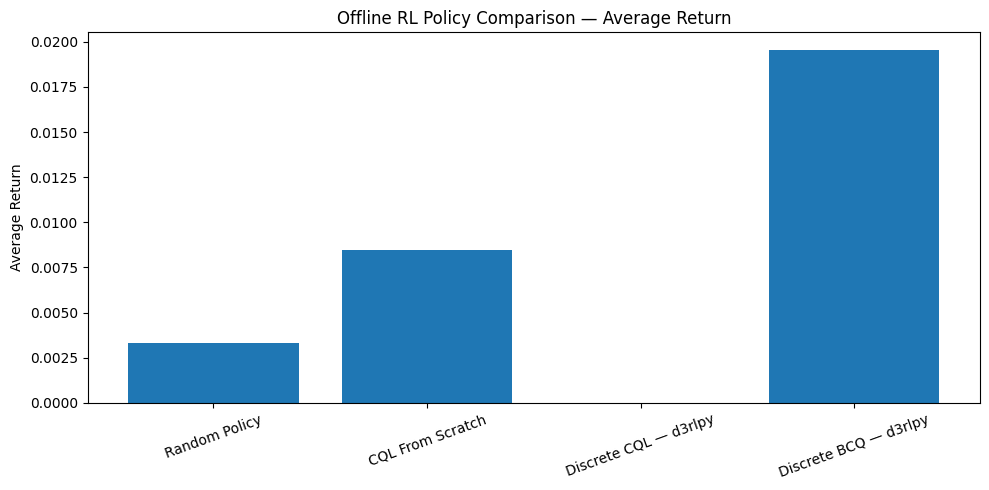

In [65]:
# Plot average return for all methods.

plt.figure(figsize=(10, 5))

plt.bar(
    results["Policy"],
    results["Average Return"]
)

plt.ylabel("Average Return")
plt.title("Offline RL Policy Comparison — Average Return")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 64. Plot Success Rate

For the navigation task, success rate is an intuitive metric alongside average return.

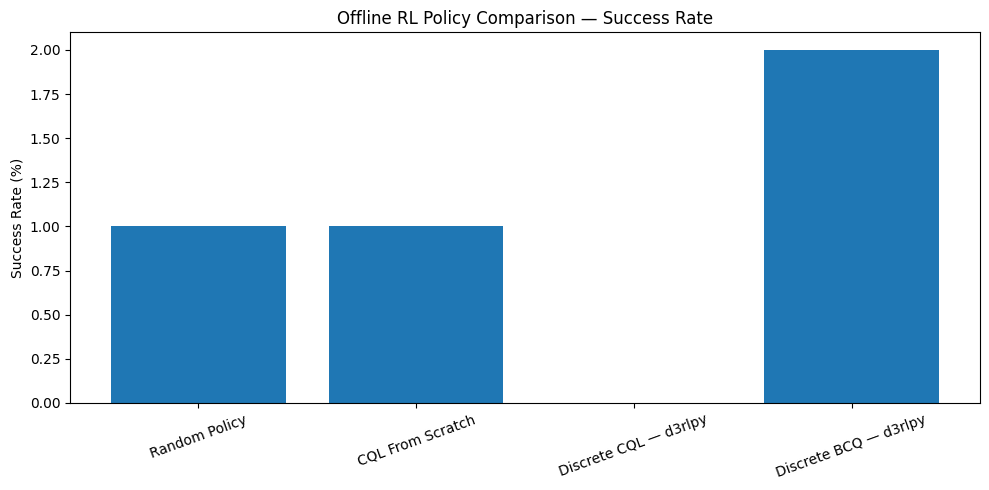

In [66]:
# Plot success rate for all methods.

plt.figure(figsize=(10, 5))

plt.bar(
    results["Policy"],
    results["Success Rate (%)"]
)

plt.ylabel("Success Rate (%)")
plt.title("Offline RL Policy Comparison — Success Rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Part VI — Interpretation

## 65. How to Interpret the Results

Do not judge the algorithms only by whether one number is larger.

Consider the dataset and method characteristics.

### If CQL performs best

That suggests conservative value regularization successfully reduced harmful Q-value overestimation while still exploiting useful trajectories.

### If BCQ performs best

That suggests action-support filtering was effective for this dataset.

### If both learned methods remain weak

That does **not automatically mean the implementation failed**.

The dataset was collected by a random behavior policy. Offline RL cannot invent high-quality experience that does not exist.

Possible causes include:

- sparse successful trajectories
- insufficient state coverage
- partial observability
- hyperparameters
- neural-network capacity
- the difficulty of generalizing from the random dataset

### If tabular CQL performs worse than deep CQL

That is expected in many cases.

The tabular method cannot generalize between similar but non-identical observations, while the neural d3rlpy implementation can learn shared representations.

## 66. Key Methodological Limitations

### From-Scratch CQL

The hand-written version is an educational tabular adaptation.

It is useful for understanding:

- Bellman targets
- conservative gradients
- offline policy learning

It is **not** intended to reproduce every implementation detail from the original CQL paper.

### Dataset Quality

The behavior policy is random.

Offline RL performance is constrained by what useful trajectories are represented in the dataset.

### Observation Representation

The deep methods flatten the `7 × 7 × 3` grid and append direction.

This is transparent and simple, but more sophisticated encoders could exploit spatial structure better.

### Environment Evaluation

This benchmark allows the original Gymnasium environment to be recovered.

In many real offline-RL applications, the real environment may not be available for online evaluation. In that situation, offline policy evaluation methods become important.

## 67. Strong Next Experiments

A portfolio-quality continuation would add controlled experiments rather than simply adding more algorithms.

### Dataset-quality experiment

Compare:

```text
Random dataset
vs
Expert dataset
```

### CQL sensitivity

Test several values of:

```text
alpha
```

### BCQ sensitivity

Test several values of:

```text
action_flexibility
```

### Additional baseline

Add Behavior Cloning.

### Offline policy evaluation

Use Fitted Q Evaluation when environment interaction is unavailable.

### Repeated evaluation

Run multiple seeds and report:

- mean
- standard deviation
- confidence interval

# 68. Final Portfolio Takeaway

This project demonstrates more than calling an offline RL library.

It shows the complete reasoning chain:

```text
Understand raw offline data
        ↓
Identify state/action/reward structure
        ↓
Construct transitions
        ↓
Understand the offline distribution-shift problem
        ↓
Implement CQL manually
        ↓
Implement deep Discrete CQL with a library
        ↓
Implement a second offline method: BCQ
        ↓
Evaluate with a common protocol
        ↓
Interpret results in light of dataset quality
```

### Skills demonstrated

- Offline Reinforcement Learning
- Minari
- Gymnasium
- MiniGrid
- Conservative Q-Learning
- Batch-Constrained Q-Learning
- d3rlpy
- Bellman learning
- conservative regularization
- discrete action support
- dataset inspection
- episodic data analysis
- experimental evaluation
- baseline comparison
- reproducible ML workflow